# SelectKBest, RFE, RandomForest

### Что нужно сделать:
1. Загрузить датасет и подготовить данные
2. Применить SelectKBest (f_regression и mutual_info)
3. Применить RFE и RFECV
4. Применить RandomForest Feature Importance
5. Сравнить все методы
6. Написать выводы

### Рекомендуемые датасеты:
- California Housing (sklearn)
- Diabetes (sklearn)
- Boston Housing (sklearn)
- Любой с Kaggle

In [11]:
# ИМПОРТЫ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Датасеты
from sklearn.datasets import fetch_california_housing

# Модели
from sklearn.ensemble import RandomForestRegressor

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.feature_selection import RFE, RFECV

# Оценка
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print(" Импорты загружены!")

 Импорты загружены!


---

## ЗАДАЧА 1: Загрузка и подготовка данных

**Описание:**  
Загрузи любой регрессионный датасет. Раздели на X (признаки) и y (target). Раздели на train/test.

**Что вывести:**
- Количество признаков и записей
- Названия признаков
- Размеры train и test

In [12]:
def load_and_prepare_data():
    """
    Загружает датасет и подготавливает данные.

    Returns:
        X: DataFrame с признаками
        y: Series с целевой переменной
        X_train, X_test, y_train, y_test: разделённые данные
    """
    # TODO: Загрузи датасет (можно использовать fetch_california_housing или другой)

    # TODO: Создай DataFrame X с признаками

    # TODO: Создай Series y с целевой переменной

    # TODO: Раздели на train/test (80/20, random_state=42)

    # TODO: Выведи информацию о данных
    dataset = fetch_california_housing()
    X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    y = pd.Series(dataset.target, name='Target')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
        )

    return X, y, X_train, X_test, y_train, y_test

# Вызови функцию
X, y, X_train, X_test, y_train, y_test = load_and_prepare_data()

---

## ЗАДАЧА 2: SelectKBest с f_regression

**Описание:**  
Примени SelectKBest с функцией f_regression. Выбери 5 лучших признаков. Выведи scores всех признаков.

**Подсказка:**  
```python
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=5)
```

In [13]:
def apply_selectkbest_f_regression(X_train, y_train, k=5):
    """
    Применяет SelectKBest с f_regression.

    Args:
        X_train: признаки для обучения
        y_train: целевая переменная
        k: количество признаков для выбора

    Returns:
        selected_features: список выбранных признаков
        scores_df: DataFrame со scores
    """
    # TODO: Создай SelectKBest с score_func=f_regression и k=k

    # TODO: Обучи selector на X_train, y_train (метод fit)

    # TODO: Получи scores из selector.scores_

    # TODO: Создай DataFrame с колонками: Feature, Score

    # TODO: Отсортируй по Score (по убыванию)

    # TODO: Получи выбранные признаки через selector.get_support()

    # TODO: Выведи результаты

    from sklearn.feature_selection import SelectKBest, f_regression
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train, y_train)
    scores = selector.scores_
    scores_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Score': scores
        }).sort_values('Score', ascending=False)

    selected_mask = selector.get_support()
    selected_features = X.columns[selected_mask].tolist()

    return selected_features, selector


# Вызови функцию
selected_f, scores_f = apply_selectkbest_f_regression(X_train, y_train, k=5)
print(f"\n Выбранные признаки: {selected_f}")


 Выбранные признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude']


---

## ЗАДАЧА 3: SelectKBest с mutual_info_regression

**Описание:**  
Примени SelectKBest с функцией mutual_info_regression. Выбери 5 лучших признаков. Сравни с f_regression.

**Подсказка:**  
```python
from sklearn.feature_selection import mutual_info_regression
selector = SelectKBest(score_func=mutual_info_regression, k=5)
```

In [14]:
def apply_selectkbest_mutual_info(X_train, y_train, k=5):
    """
    Применяет SelectKBest с mutual_info_regression.

    Args:
        X_train: признаки для обучения
        y_train: целевая переменная
        k: количество признаков для выбора

    Returns:
        selected_features: список выбранных признаков
        scores_df: DataFrame со scores
    """
    # TODO: Создай SelectKBest с score_func=mutual_info_regression и k=k

    # TODO: Обучи selector на X_train, y_train

    # TODO: Получи scores из selector.scores_

    # TODO: Создай DataFrame с колонками: Feature, Score

    # TODO: Отсортируй по Score (по убыванию)

    # TODO: Получи выбранные признаки

    # TODO: Выведи результаты

    from sklearn.feature_selection import mutual_info_regression
    selector = SelectKBest(score_func=mutual_info_regression, k=k)

    selector.fit(X_train, y_train)

    scores = selector.scores_
    scores_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Score': scores
    }).sort_values('Score', ascending=False)

    selected_features = X_train.columns[selector.get_support()].tolist()
    return selected_features, scores_df

# Вызови функцию
selected_mi, scores_mi = apply_selectkbest_mutual_info(X_train, y_train, k=5)
print(f"\n Выбранные признаки: {selected_mi}")


 Выбранные признаки: ['MedInc', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']


---

## ЗАДАЧА 4: Визуализация SelectKBest

**Описание:**  
Создай bar plot для сравнения scores f_regression и mutual_info. Выдели выбранные признаки цветом.

In [15]:
def plot_selectkbest_results(scores_f, scores_mi, selected_f, selected_mi):
    """
    Визуализирует результаты SelectKBest.

    Args:
        scores_f: DataFrame со scores f_regression
        scores_mi: DataFrame со scores mutual_info
        selected_f: выбранные признаки (f_regression)
        selected_mi: выбранные признаки (mutual_info)
    """
    # TODO: Создай figure с двумя subplots (1 строка, 2 колонки)

    # TODO: На первом графике — bar plot для f_regression
    #       Выбранные признаки покрась зелёным, остальные серым

    # TODO: На втором графике — bar plot для mutual_info
    #       Выбранные признаки покрась оранжевым, остальные серым

    # TODO: Добавь заголовки и подписи осей

    # TODO: Покажи график

    pass


# Вызови функцию
plot_selectkbest_results(scores_f, scores_mi, selected_f, selected_mi)

---

## ЗАДАЧА 5: RFE (Recursive Feature Elimination)

**Описание:**  
Примени RFE с RandomForestRegressor. Выбери 5 признаков. Выведи ранги всех признаков.

**Подсказка:**  
```python
from sklearn.feature_selection import RFE
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train, y_train)
# rfe.ranking_ — ранги признаков (1 = лучший)
# rfe.support_ — маска выбранных признаков
```

In [16]:
def apply_rfe(X_train, y_train, n_features=5):
    """
    Применяет RFE для отбора признаков.

    Args:
        X_train: признаки для обучения
        y_train: целевая переменная
        n_features: количество признаков для выбора

    Returns:
        selected_features: список выбранных признаков
        ranking_df: DataFrame с рангами
    """
    # TODO: Создай модель RandomForestRegressor (n_estimators=100, random_state=42)
    estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    # TODO: Создай RFE с этой моделью и n_features_to_select=n_features

    # TODO: Обучи RFE на X_train, y_train

    # TODO: Создай DataFrame с колонками: Feature, Ranking, Selected
    #       Ranking из rfe.ranking_, Selected из rfe.support_

    # TODO: Отсортируй по Ranking

    # TODO: Получи список выбранных признаков

    # TODO: Выведи результаты


    rfe = RFE(estimator=estimator, n_features_to_select=n_features, step=1)
    rfe.fit(X_train, y_train)

    ranking_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Ranking': rfe.ranking_,
        'Selected': rfe.support_
    }).sort_values('Ranking', ascending=True).reset_index(drop=True)

    selected_features = X_train.columns[rfe.support_].tolist()

    return selected_features, ranking_df, rfe



# Вызови функцию
selected_rfe, ranking_rfe, rfe_model = apply_rfe(X_train, y_train, n_features=5)
print(f"\n Выбранные признаки: {selected_rfe}")


 Выбранные признаки: ['MedInc', 'HouseAge', 'AveOccup', 'Latitude', 'Longitude']


---

## ЗАДАЧА 6: RFECV (автоматический выбор K)

**Описание:**  
Примени RFECV для автоматического выбора оптимального количества признаков. Построй график CV scores.

**Подсказка:**  
```python
from sklearn.feature_selection import RFECV
rfecv = RFECV(estimator=model, cv=5, scoring='r2')
rfecv.fit(X_train, y_train)
# rfecv.n_features_ — оптимальное количество
# rfecv.cv_results_['mean_test_score'] — средние scores по CV
```

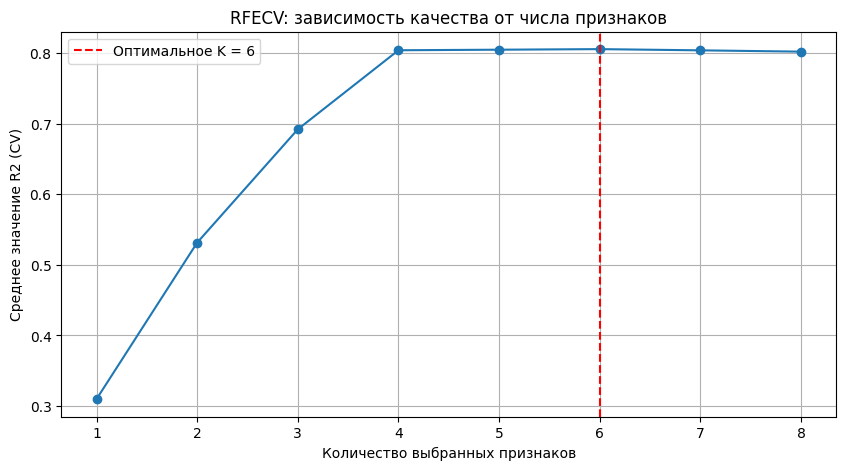


 Оптимальное количество: 6
 Выбранные признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']


In [17]:
def apply_rfecv(X_train, y_train, cv=5):
    """
    Применяет RFECV для автоматического выбора количества признаков.

    Args:
        X_train: признаки для обучения
        y_train: целевая переменная
        cv: количество фолдов для кросс-валидации

    Returns:
        selected_features: список выбранных признаков
        optimal_n: оптимальное количество признаков
        rfecv: обученный объект RFECV (для графика)
    """
    # TODO: Создай модель RandomForestRegressor (n_estimators=50, random_state=42)

    # TODO: Создай RFECV с cv=cv, scoring='r2'

    # TODO: Обучи RFECV на X_train, y_train

    # TODO: Получи оптимальное количество из rfecv.n_features_

    # TODO: Получи список выбранных признаков

    # TODO: Выведи результаты


    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

    rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='r2', n_jobs=-1)
    rfecv.fit(X_train, y_train)
    optimal_n = rfecv.n_features_

    selected_features = X_train.columns[rfecv.support_].tolist()

    mean_scores = rfecv.cv_results_['mean_test_score']
    n_features = range(1, len(mean_scores) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(n_features, mean_scores, marker='o')
    plt.axvline(optimal_n, color='red', linestyle='--', label=f'Оптимальное K = {optimal_n}')
    plt.xlabel("Количество выбранных признаков")
    plt.ylabel("Среднее значение R2 (CV)")
    plt.title("RFECV: зависимость качества от числа признаков")
    plt.legend()
    plt.grid(True)
    plt.show()

    return selected_features, optimal_n, rfecv

# Вызови функцию
selected_rfecv, optimal_n, rfecv_model = apply_rfecv(X_train, y_train, cv=5)
print(f"\n Оптимальное количество: {optimal_n}")
print(f" Выбранные признаки: {selected_rfecv}")

---

## ЗАДАЧА 7: Визуализация RFECV

**Описание:**  
Построй график: R² Score vs количество признаков. Отметь оптимальное количество вертикальной линией.

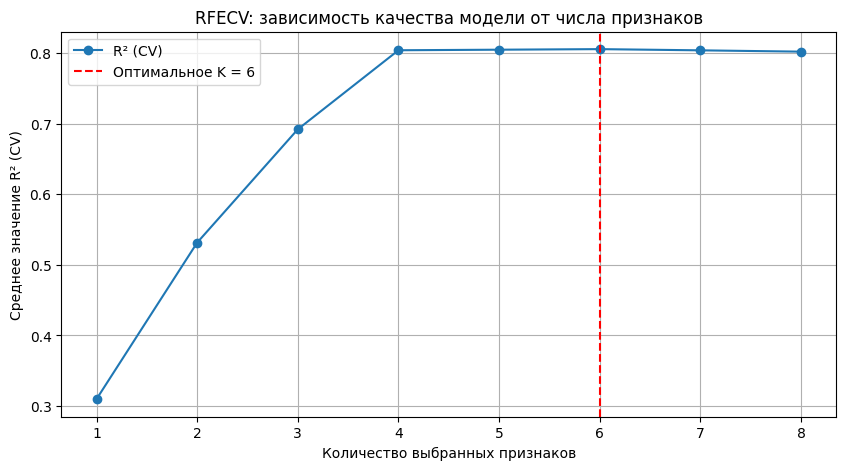

In [18]:
def plot_rfecv_results(rfecv_model):
    """
    Визуализирует результаты RFECV.

    Args:
        rfecv_model: обученный объект RFECV
    """
    # TODO: Создай figure

    # TODO: Получи mean_test_score из rfecv_model.cv_results_['mean_test_score']

    # TODO: Построй линейный график (x = количество признаков, y = R² score)

    # TODO: Добавь вертикальную линию на оптимальном количестве

    # TODO: Добавь заголовок, подписи осей, легенду

    # TODO: Покажи график

    n_features = range(1, len(rfecv_model.cv_results_['mean_test_score']) + 1)

    mean_scores = rfecv_model.cv_results_['mean_test_score']
    plt.figure(figsize=(10, 5))
    plt.plot(n_features, mean_scores, marker='o', label='R² (CV)')
    plt.axvline(rfecv_model.n_features_, color='red', linestyle='--',
                label=f'Оптимальное K = {rfecv_model.n_features_}')

    plt.xlabel("Количество выбранных признаков")
    plt.ylabel("Среднее значение R² (CV)")
    plt.title("RFECV: зависимость качества модели от числа признаков")
    plt.legend()
    plt.grid(True)
    plt.show()


# Вызови функцию
plot_rfecv_results(rfecv_model)

---

## ЗАДАЧА 8: RandomForest Feature Importance

**Описание:**  
Обучи RandomForest и получи Feature Importance. Отбери признаки, которые дают 80% суммарной важности.

**Подсказка:**  
```python
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
```

In [19]:
def get_rf_feature_importance(X_train, y_train, threshold_pct=80):
    """
    Вычисляет Feature Importance и отбирает признаки.

    Args:
        X_train: признаки для обучения
        y_train: целевая переменная
        threshold_pct: порог cumsum в процентах (по умолчанию 80%)

    Returns:
        importance_df: DataFrame с важностью признаков
        selected_features: признаки, дающие threshold_pct% важности
    """
    # TODO: Создай и обучи RandomForestRegressor

    # TODO: Получи feature_importances_ из модели

    # TODO: Создай DataFrame с колонками: Feature, Importance

    # TODO: Отсортируй по Importance (по убыванию)

    # TODO: Добавь колонку Importance_Pct (проценты)

    # TODO: Добавь колонку Cumsum_Pct (накопленные проценты)

    # TODO: Отбери признаки, которые дают threshold_pct% важности

    # TODO: Выведи результаты

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    importances = rf.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    importance_df['Importance_Pct'] = importance_df['Importance'] * 100
    importance_df['Cumsum_Pct'] = importance_df['Importance_Pct'].cumsum()

    selected_features = importance_df[importance_df['Cumsum_Pct'] <= threshold_pct]['Feature'].tolist()

    return importance_df, selected_features

# Вызови функцию
importance_df, selected_rf = get_rf_feature_importance(X_train, y_train, threshold_pct=80)
print(f"\n Выбранные признаки (80% важности): {selected_rf}")


 Выбранные признаки (80% важности): ['MedInc', 'AveOccup', 'Latitude']


---

## ЗАДАЧА 9: Визуализация Feature Importance

**Описание:**  
Создай два графика:  
1. Bar plot с важностью каждого признака (в процентах)  
2. Line plot с накопленной важностью (cumsum)

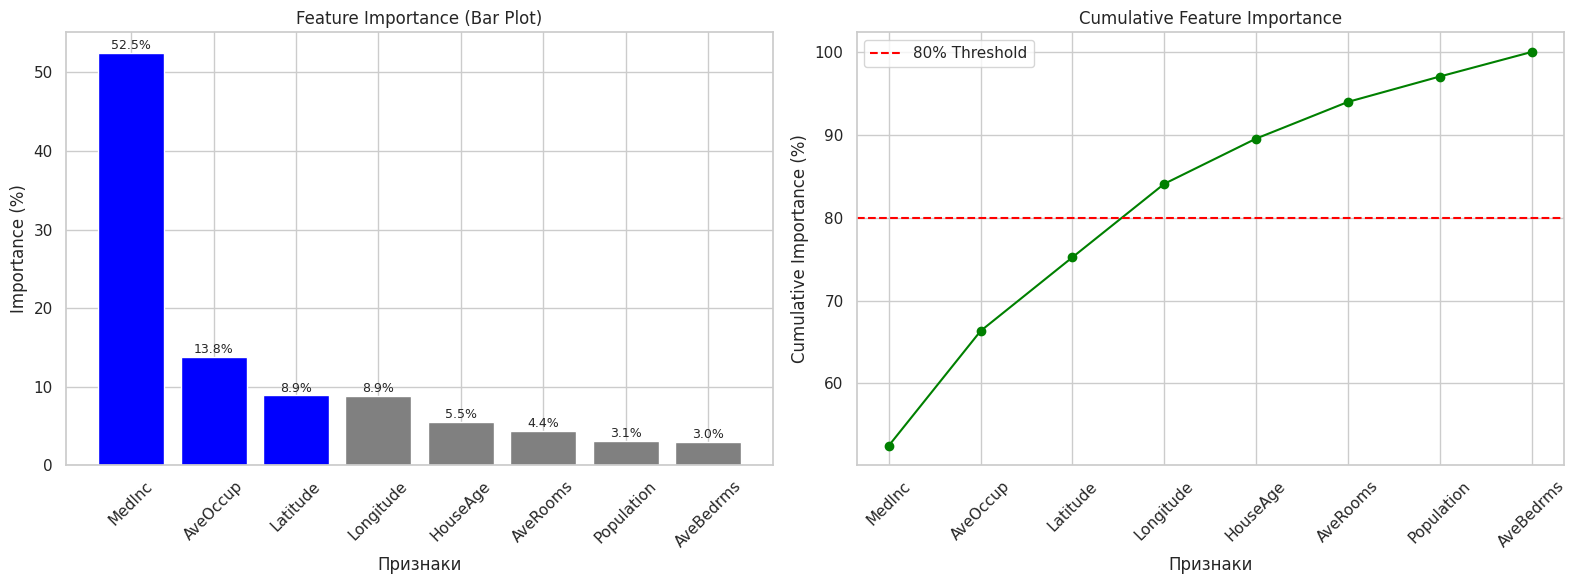

In [21]:
def plot_feature_importance(importance_df, selected_rf):
    """
    Визуализирует Feature Importance.

    Args:
        importance_df: DataFrame с важностью
        selected_rf: выбранные признаки
    """
    # TODO: Создай figure с двумя subplots

    # TODO: На первом графике — bar plot важности
    #       Выбранные признаки покрась синим, остальные серым
    #       Добавь проценты на столбцы

    # TODO: На втором графике — line plot cumsum
    #       Добавь горизонтальную линию на 80%

    # TODO: Добавь заголовки и подписи осей

    # TODO: Покажи график

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['blue' if f in selected_rf else 'gray' for f in importance_df['Feature']]
    axes[0].bar(importance_df['Feature'], importance_df['Importance_Pct'], color=colors)
    axes[0].set_xlabel('Признаки')
    axes[0].set_ylabel('Importance (%)')
    axes[0].set_title('Feature Importance (Bar Plot)')
    axes[0].tick_params(axis='x', rotation=45)
    for idx, val in enumerate(importance_df['Importance_Pct']):
        axes[0].text(idx, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9)

    axes[1].plot(importance_df['Feature'], importance_df['Cumsum_Pct'], marker='o', color='green')
    axes[1].axhline(80, color='red', linestyle='--', label='80% Threshold')
    axes[1].set_xlabel('Признаки')
    axes[1].set_ylabel('Cumulative Importance (%)')
    axes[1].set_title('Cumulative Feature Importance')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Вызови функцию
plot_feature_importance(importance_df, selected_rf)